# Week 13: CCE-Error Correlation for CODE GENERATION

## Hypothesis

CCE spikes during code generation predict tokens that will cause errors (syntax errors, runtime errors, wrong output).

## Why This is Different from Q&A

Previous experiment (Week13_V2) tested CCE on factual Q&A:
- Result: r=0.065, p=0.428 (NO correlation)
- Q&A answers are short, model is confident even when wrong

Code generation is different:
- **Longer outputs** with more opportunity for CCE variation
- **Objective verification** via execution (syntax check, runtime check, output check)
- **Closer to Gnosis paper's original use case**
- **Token-level error attribution** - we know WHICH token caused the error

## Experiment Design

1. Generate Python code using httpx for various tasks
2. Record CCE at every token position
3. Execute the code and classify errors:
   - Syntax error (which line/token?)
   - Runtime error (which line/token?)
   - Wrong output (semantic error)
4. Correlate CCE at error-causing tokens vs correct tokens

In [18]:
# Install dependencies
!pip install -q torch transformers accelerate bitsandbytes httpx scipy numpy pandas matplotlib

In [2]:
import os
import re
import ast
import sys
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import traceback
import subprocess
import tempfile
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass, field
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import matplotlib.pyplot as plt
from scipy import stats
from io import StringIO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [3]:
# Load model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model loaded!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/646 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded!


## Code Generation Tasks

Tasks that require generating executable Python code using httpx.

In [4]:
# Code generation tasks with expected behavior
CODE_TASKS = [
    # Basic GET requests
    {
        'id': 'task01',
        'prompt': 'Write Python code using httpx to make a GET request to https://httpbin.org/get and print the status code.',
        'test_contains': ['httpx', 'get', 'httpbin.org/get', 'status_code'],
        'should_execute': True,
    },
    {
        'id': 'task02',
        'prompt': 'Write Python code using httpx to make a GET request with query parameters name=alice and age=30 to https://httpbin.org/get',
        'test_contains': ['httpx', 'params', 'alice', '30'],
        'should_execute': True,
    },
    {
        'id': 'task03',
        'prompt': 'Write Python code using httpx to make a GET request with custom headers User-Agent: MyApp/1.0 to https://httpbin.org/headers',
        'test_contains': ['httpx', 'headers', 'User-Agent', 'MyApp'],
        'should_execute': True,
    },

    # POST requests
    {
        'id': 'task04',
        'prompt': 'Write Python code using httpx to POST JSON data {"name": "test"} to https://httpbin.org/post',
        'test_contains': ['httpx', 'post', 'json'],
        'should_execute': True,
    },
    {
        'id': 'task05',
        'prompt': 'Write Python code using httpx to POST form data with fields username=admin and password=secret to https://httpbin.org/post',
        'test_contains': ['httpx', 'post', 'data', 'username', 'password'],
        'should_execute': True,
    },

    # Client usage
    {
        'id': 'task06',
        'prompt': 'Write Python code using httpx Client as a context manager to make two GET requests to https://httpbin.org/get',
        'test_contains': ['httpx', 'Client', 'with', 'get'],
        'should_execute': True,
    },
    {
        'id': 'task07',
        'prompt': 'Write Python code using httpx Client with a base_url of https://httpbin.org to make a GET request to /get',
        'test_contains': ['httpx', 'Client', 'base_url'],
        'should_execute': True,
    },

    # Timeout handling
    {
        'id': 'task08',
        'prompt': 'Write Python code using httpx to make a GET request with a 5 second timeout to https://httpbin.org/get',
        'test_contains': ['httpx', 'timeout', '5'],
        'should_execute': True,
    },
    {
        'id': 'task09',
        'prompt': 'Write Python code using httpx to make a GET request and catch TimeoutException if it times out',
        'test_contains': ['httpx', 'try', 'except', 'Timeout'],
        'should_execute': True,
    },

    # Response handling
    {
        'id': 'task10',
        'prompt': 'Write Python code using httpx to GET https://httpbin.org/json and parse the JSON response',
        'test_contains': ['httpx', 'get', 'json()'],
        'should_execute': True,
    },
    {
        'id': 'task11',
        'prompt': 'Write Python code using httpx to GET a URL and check if the response was successful using is_success',
        'test_contains': ['httpx', 'is_success'],
        'should_execute': True,
    },
    {
        'id': 'task12',
        'prompt': 'Write Python code using httpx to make a request and call raise_for_status() to raise an exception on error',
        'test_contains': ['httpx', 'raise_for_status'],
        'should_execute': True,
    },

    # Authentication
    {
        'id': 'task13',
        'prompt': 'Write Python code using httpx BasicAuth to make an authenticated request to https://httpbin.org/basic-auth/user/pass',
        'test_contains': ['httpx', 'BasicAuth', 'auth'],
        'should_execute': True,
    },

    # Async client
    {
        'id': 'task14',
        'prompt': 'Write Python code using httpx AsyncClient to make an async GET request to https://httpbin.org/get',
        'test_contains': ['httpx', 'AsyncClient', 'async', 'await'],
        'should_execute': False,  # Async code needs special handling
    },

    # Redirects
    {
        'id': 'task15',
        'prompt': 'Write Python code using httpx to make a GET request that follows redirects using follow_redirects=True',
        'test_contains': ['httpx', 'follow_redirects', 'True'],
        'should_execute': True,
    },

    # Error scenarios (harder - likely to cause errors)
    {
        'id': 'task16',
        'prompt': 'Write Python code using httpx to upload a file named test.txt to https://httpbin.org/post',
        'test_contains': ['httpx', 'files', 'post'],
        'should_execute': False,  # File doesn't exist
    },
    {
        'id': 'task17',
        'prompt': 'Write Python code using httpx to make multiple concurrent requests using asyncio.gather',
        'test_contains': ['httpx', 'asyncio', 'gather'],
        'should_execute': False,  # Async
    },
    {
        'id': 'task18',
        'prompt': 'Write Python code using httpx to stream a large response and iterate over chunks',
        'test_contains': ['httpx', 'stream', 'iter'],
        'should_execute': True,
    },
    {
        'id': 'task19',
        'prompt': 'Write Python code using httpx to make a request through a proxy server at http://proxy.example.com:8080',
        'test_contains': ['httpx', 'proxy', 'proxies'],
        'should_execute': False,  # No proxy available
    },
    {
        'id': 'task20',
        'prompt': 'Write Python code using httpx to make an HTTP/2 request by setting http2=True',
        'test_contains': ['httpx', 'http2', 'True'],
        'should_execute': True,
    },
]

print(f"Defined {len(CODE_TASKS)} code generation tasks")

Defined 20 code generation tasks


## Code Generation with CCE Tracking

In [5]:
@dataclass
class CodeGenerationResult:
    task_id: str
    prompt: str
    generated_code: str
    tokens: List[int]
    token_strings: List[str]
    cce_per_token: List[float]

    # Error info
    has_syntax_error: bool = False
    syntax_error_line: Optional[int] = None
    syntax_error_msg: str = ""

    has_runtime_error: bool = False
    runtime_error_line: Optional[int] = None
    runtime_error_msg: str = ""
    runtime_error_type: str = ""

    execution_success: bool = False

    @property
    def has_error(self) -> bool:
        return self.has_syntax_error or self.has_runtime_error

    @property
    def mean_cce(self) -> float:
        return np.mean(self.cce_per_token) if self.cce_per_token else 0.0

    @property
    def max_cce(self) -> float:
        return np.max(self.cce_per_token) if self.cce_per_token else 0.0

    @property
    def cce_std(self) -> float:
        return np.std(self.cce_per_token) if self.cce_per_token else 0.0

In [6]:
def generate_code_with_cce(
    model, tokenizer, prompt: str,
    max_tokens: int = 300, temperature: float = 0.0,
) -> Tuple[str, List[int], List[str], List[float]]:
    """Generate code and track CCE at each token position."""

    full_prompt = f"""[INST] Write only Python code, no explanations. Do not include markdown code blocks.

{prompt} [/INST]

```python
"""

    input_ids = tokenizer.encode(full_prompt, return_tensors='pt').to(model.device)

    cce_values = []
    generated_tokens = []
    token_strings = []

    with torch.no_grad():
        for _ in range(max_tokens):
            outputs = model(input_ids)
            logits = outputs.logits[:, -1, :].float()

            # CCE in bits (no temperature scaling for entropy)
            probs = F.softmax(logits, dim=-1)
            log2_probs = torch.log2(probs + 1e-10)
            entropy = -(probs * log2_probs).sum(dim=-1).item()
            cce_values.append(entropy)

            # Sample next token
            if temperature == 0:
                next_token = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                probs_temp = F.softmax(logits / temperature, dim=-1)
                next_token = torch.multinomial(probs_temp, num_samples=1)

            token_id = next_token.item()
            generated_tokens.append(token_id)
            token_strings.append(tokenizer.decode([token_id]))

            input_ids = torch.cat([input_ids, next_token], dim=-1)

            # Stop on EOS or code block end
            if token_id == tokenizer.eos_token_id:
                break

            # Check for code block end
            decoded = tokenizer.decode(generated_tokens[-10:] if len(generated_tokens) >= 10 else generated_tokens)
            if '```' in decoded and len(generated_tokens) > 20:
                break

    # Decode full response
    full_response = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return full_response, generated_tokens, token_strings, cce_values

In [7]:
def extract_python_code(text: str) -> str:
    """Extract Python code from generated text."""
    # Remove markdown code blocks if present
    text = text.replace('```python', '').replace('```', '')

    # Clean up
    lines = text.strip().split('\n')
    code_lines = []
    for line in lines:
        # Skip obvious non-code lines
        if line.strip().startswith('#') or line.strip() == '' or 'import' in line or line.strip().startswith(('def ', 'class ', 'if ', 'for ', 'while ', 'with ', 'try:', 'except', 'print', 'return', 'response', 'client', 'httpx', '    ', '\t')):
            code_lines.append(line)
        elif '=' in line or '(' in line:
            code_lines.append(line)

    return '\n'.join(code_lines) if code_lines else text

In [8]:
def check_syntax(code: str) -> Tuple[bool, Optional[int], str]:
    """Check if code has syntax errors.
    Returns: (has_error, error_line, error_message)
    """
    try:
        ast.parse(code)
        return False, None, ""
    except SyntaxError as e:
        return True, e.lineno, str(e)


def execute_code(code: str, timeout: int = 10) -> Tuple[bool, bool, Optional[int], str, str]:
    """Execute code in isolated subprocess.
    Returns: (success, has_runtime_error, error_line, error_type, error_message)
    """
    # First check syntax
    has_syntax, syntax_line, syntax_msg = check_syntax(code)
    if has_syntax:
        return False, False, syntax_line, 'SyntaxError', syntax_msg

    # Write to temp file
    with tempfile.NamedTemporaryFile(mode='w', suffix='.py', delete=False) as f:
        f.write(code)
        temp_path = f.name

    try:
        result = subprocess.run(
            [sys.executable, temp_path],
            capture_output=True,
            text=True,
            timeout=timeout,
        )

        if result.returncode == 0:
            return True, False, None, "", ""
        else:
            # Parse error from stderr
            stderr = result.stderr
            error_line = None
            error_type = "RuntimeError"

            # Try to extract line number
            line_match = re.search(r'line (\d+)', stderr)
            if line_match:
                error_line = int(line_match.group(1))

            # Try to extract error type
            type_match = re.search(r'(\w+Error|\w+Exception):', stderr)
            if type_match:
                error_type = type_match.group(1)

            return False, True, error_line, error_type, stderr

    except subprocess.TimeoutExpired:
        return False, True, None, "TimeoutError", "Execution timed out"
    except Exception as e:
        return False, True, None, type(e).__name__, str(e)
    finally:
        os.unlink(temp_path)


# Test
test_code = "print('hello')\nimport httpx\nresponse = httpx.get('https://httpbin.org/get')\nprint(response.status_code)"
print("Test code:")
print(test_code)
print("\nSyntax check:", check_syntax(test_code))
print("Execution:", execute_code(test_code))

Test code:
print('hello')
import httpx
response = httpx.get('https://httpbin.org/get')
print(response.status_code)

Syntax check: (False, None, '')
Execution: (True, False, None, '', '')


In [9]:
def evaluate_code_generation(task: Dict, result: CodeGenerationResult) -> CodeGenerationResult:
    """Evaluate generated code for syntax and runtime errors."""

    code = extract_python_code(result.generated_code)
    result.generated_code = code  # Store cleaned code

    # Check syntax
    has_syntax, syntax_line, syntax_msg = check_syntax(code)
    result.has_syntax_error = has_syntax
    result.syntax_error_line = syntax_line
    result.syntax_error_msg = syntax_msg

    if has_syntax:
        return result

    # Execute if requested
    if task.get('should_execute', False):
        success, has_runtime, error_line, error_type, error_msg = execute_code(code)
        result.execution_success = success
        result.has_runtime_error = has_runtime
        result.runtime_error_line = error_line
        result.runtime_error_type = error_type
        result.runtime_error_msg = error_msg
    else:
        # Just check syntax is enough
        result.execution_success = not has_syntax

    return result

## Run Code Generation Experiment

In [10]:
%%time

results = []

for i, task in enumerate(CODE_TASKS):
    print(f"\n[{i+1}/{len(CODE_TASKS)}] {task['id']}: {task['prompt'][:60]}...")

    # Generate code with CCE tracking
    code, tokens, token_strs, cce_vals = generate_code_with_cce(
        model, tokenizer, task['prompt'],
        max_tokens=300,
        temperature=0.0,
    )

    result = CodeGenerationResult(
        task_id=task['id'],
        prompt=task['prompt'],
        generated_code=code,
        tokens=tokens,
        token_strings=token_strs,
        cce_per_token=cce_vals,
    )

    # Evaluate
    result = evaluate_code_generation(task, result)
    results.append(result)

    # Report
    status = "OK" if result.execution_success else "ERR"
    if result.has_syntax_error:
        status = f"SYNTAX_ERR (line {result.syntax_error_line})"
    elif result.has_runtime_error:
        status = f"{result.runtime_error_type} (line {result.runtime_error_line})"

    print(f"  Status: {status}")
    print(f"  CCE: mean={result.mean_cce:.3f}, max={result.max_cce:.3f}, std={result.cce_std:.3f}")
    print(f"  Tokens: {len(tokens)}")

print(f"\n{'='*60}")
print(f"Completed {len(results)} tasks")
print(f"Success: {sum(1 for r in results if r.execution_success)}/{len(results)}")
print(f"Syntax errors: {sum(1 for r in results if r.has_syntax_error)}")
print(f"Runtime errors: {sum(1 for r in results if r.has_runtime_error)}")


[1/20] task01: Write Python code using httpx to make a GET request to https...
  Status: OK
  CCE: mean=0.047, max=0.772, std=0.150
  Tokens: 32

[2/20] task02: Write Python code using httpx to make a GET request with que...
  Status: OK
  CCE: mean=0.160, max=1.818, std=0.433
  Tokens: 46

[3/20] task03: Write Python code using httpx to make a GET request with cus...
  Status: OK
  CCE: mean=0.153, max=2.532, std=0.477
  Tokens: 46

[4/20] task04: Write Python code using httpx to POST JSON data {"name": "te...
  Status: OK
  CCE: mean=0.170, max=2.112, std=0.474
  Tokens: 39

[5/20] task05: Write Python code using httpx to POST form data with fields ...
  Status: OK
  CCE: mean=0.191, max=2.598, std=0.512
  Tokens: 46

[6/20] task06: Write Python code using httpx Client as a context manager to...
  Status: OK
  CCE: mean=0.132, max=1.635, std=0.312
  Tokens: 73

[7/20] task07: Write Python code using httpx Client with a base_url of http...
  Status: OK
  CCE: mean=0.156, max=1.708, s

## Analysis: CCE vs Error Correlation

In [11]:
# Task-level analysis (like Q&A experiment)
print("="*60)
print("TASK-LEVEL ANALYSIS")
print("="*60)

task_data = []
for r in results:
    task_data.append({
        'task_id': r.task_id,
        'mean_cce': r.mean_cce,
        'max_cce': r.max_cce,
        'cce_std': r.cce_std,
        'num_tokens': len(r.tokens),
        'has_error': r.has_error,
        'error': 1 if r.has_error else 0,
        'execution_success': r.execution_success,
    })

df_tasks = pd.DataFrame(task_data)

# Correlation
r_mean, p_mean = stats.pearsonr(df_tasks['mean_cce'], df_tasks['error'])
r_max, p_max = stats.pearsonr(df_tasks['max_cce'], df_tasks['error'])

print(f"\nCorrelation (mean_cce vs error): r={r_mean:.3f}, p={p_mean:.4f}")
print(f"Correlation (max_cce vs error):  r={r_max:.3f}, p={p_max:.4f}")

# T-test
success_cce = df_tasks[df_tasks['has_error'] == False]['mean_cce']
error_cce = df_tasks[df_tasks['has_error'] == True]['mean_cce']

if len(success_cce) > 1 and len(error_cce) > 1:
    t_stat, t_p = stats.ttest_ind(success_cce, error_cce)
    print(f"\nT-test:")
    print(f"  Mean CCE (success, n={len(success_cce)}): {success_cce.mean():.3f}")
    print(f"  Mean CCE (error, n={len(error_cce)}):   {error_cce.mean():.3f}")
    print(f"  t={t_stat:.3f}, p={t_p:.4f}")
else:
    print(f"\nNot enough samples for t-test (success={len(success_cce)}, error={len(error_cce)})")
    t_stat, t_p = 0, 1

TASK-LEVEL ANALYSIS

Correlation (mean_cce vs error): r=0.332, p=0.1527
Correlation (max_cce vs error):  r=0.303, p=0.1945

T-test:
  Mean CCE (success, n=15): 0.196
  Mean CCE (error, n=5):   0.276
  t=-1.493, p=0.1527


In [12]:
# Token-level analysis (NEW - specific to code generation)
print("="*60)
print("TOKEN-LEVEL ANALYSIS")
print("="*60)

def map_line_to_tokens(result: CodeGenerationResult) -> Dict[int, List[int]]:
    """Map each line number to the token indices that generated it."""
    line_to_tokens = {}
    current_line = 1

    for i, token_str in enumerate(result.token_strings):
        if current_line not in line_to_tokens:
            line_to_tokens[current_line] = []
        line_to_tokens[current_line].append(i)

        # Count newlines in token
        current_line += token_str.count('\n')

    return line_to_tokens


def get_error_token_indices(result: CodeGenerationResult) -> List[int]:
    """Get indices of tokens on error-causing lines."""
    error_indices = []

    if not result.has_error:
        return error_indices

    error_line = result.syntax_error_line or result.runtime_error_line
    if error_line is None:
        return error_indices

    line_to_tokens = map_line_to_tokens(result)

    # Get tokens from error line and surrounding lines
    for line in range(max(1, error_line - 1), error_line + 2):
        if line in line_to_tokens:
            error_indices.extend(line_to_tokens[line])

    return error_indices


# Collect token-level CCE data
token_level_data = []

for result in results:
    error_token_indices = set(get_error_token_indices(result))

    for i, (cce, token_str) in enumerate(zip(result.cce_per_token, result.token_strings)):
        is_error_token = i in error_token_indices
        token_level_data.append({
            'task_id': result.task_id,
            'token_idx': i,
            'token_str': token_str,
            'cce': cce,
            'is_error_token': is_error_token,
            'error': 1 if is_error_token else 0,
        })

df_tokens = pd.DataFrame(token_level_data)
print(f"Total tokens analyzed: {len(df_tokens)}")
print(f"Error tokens: {df_tokens['error'].sum()}")
print(f"Non-error tokens: {len(df_tokens) - df_tokens['error'].sum()}")

# Token-level correlation
if df_tokens['error'].sum() > 0:
    r_token, p_token = stats.pearsonr(df_tokens['cce'], df_tokens['error'])
    print(f"\nToken-level correlation: r={r_token:.4f}, p={p_token:.6f}")

    # T-test
    error_token_cce = df_tokens[df_tokens['is_error_token'] == True]['cce']
    normal_token_cce = df_tokens[df_tokens['is_error_token'] == False]['cce']

    if len(error_token_cce) > 1 and len(normal_token_cce) > 1:
        t_token, p_token_t = stats.ttest_ind(error_token_cce, normal_token_cce)
        print(f"\nToken T-test:")
        print(f"  Mean CCE (normal tokens, n={len(normal_token_cce)}): {normal_token_cce.mean():.3f}")
        print(f"  Mean CCE (error tokens, n={len(error_token_cce)}):  {error_token_cce.mean():.3f}")
        print(f"  t={t_token:.3f}, p={p_token_t:.6f}")
else:
    print("No error tokens identified for token-level analysis")

TOKEN-LEVEL ANALYSIS
Total tokens analyzed: 1177
Error tokens: 135
Non-error tokens: 1042

Token-level correlation: r=0.0346, p=0.236056

Token T-test:
  Mean CCE (normal tokens, n=1042): 0.225
  Mean CCE (error tokens, n=135):  0.279
  t=1.186, p=0.236056


In [13]:
# CCE spike analysis
print("="*60)
print("CCE SPIKE ANALYSIS")
print("="*60)

# Define spike thresholds
THRESHOLDS = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

print("\nSpike analysis by threshold:")
print(f"{'Threshold':<12} {'Total Spikes':<15} {'At Error Tokens':<18} {'Precision':<12}")
print("-" * 60)

for threshold in THRESHOLDS:
    # Count spikes
    df_tokens['is_spike'] = df_tokens['cce'] > threshold
    total_spikes = df_tokens['is_spike'].sum()
    spikes_at_errors = df_tokens[(df_tokens['is_spike']) & (df_tokens['is_error_token'])].shape[0]

    precision = spikes_at_errors / total_spikes if total_spikes > 0 else 0

    print(f"{threshold:<12.1f} {total_spikes:<15} {spikes_at_errors:<18} {precision:<12.3f}")

CCE SPIKE ANALYSIS

Spike analysis by threshold:
Threshold    Total Spikes    At Error Tokens    Precision   
------------------------------------------------------------
1.0          108             14                 0.130       
1.5          62              6                  0.097       
2.0          20              2                  0.100       
2.5          8               1                  0.125       
3.0          0               0                  0.000       
3.5          0               0                  0.000       
4.0          0               0                  0.000       


/tmp/ipython-input-735559325.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([normal_token_cce, error_token_cce], labels=['Normal Tokens', 'Error Tokens'])


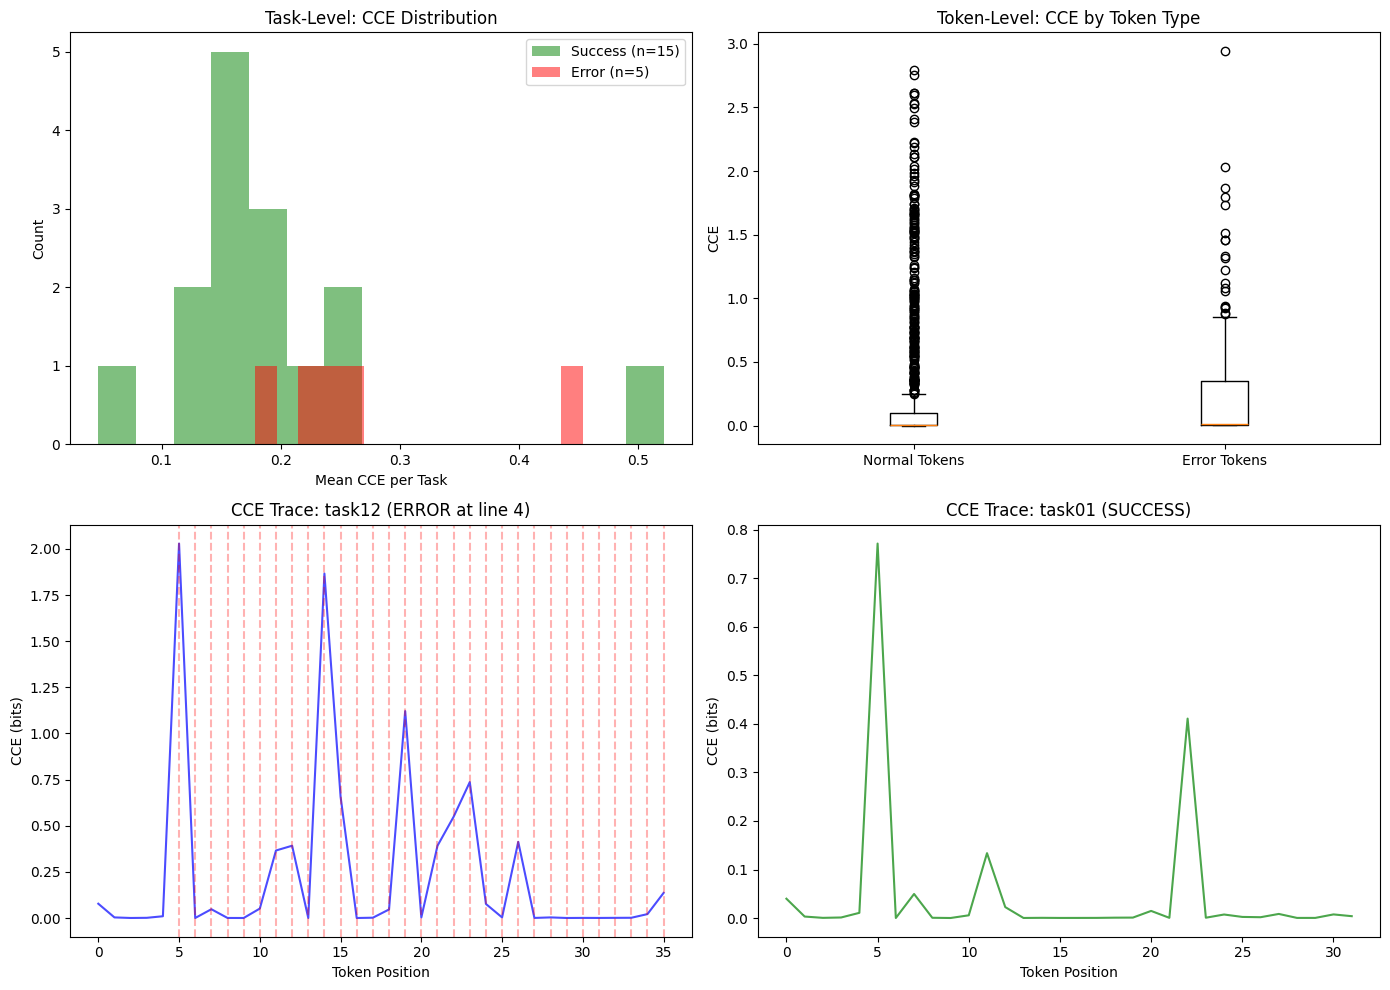

In [14]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Task-level: CCE distribution by success/error
ax1 = axes[0, 0]
ax1.hist(success_cce, bins=15, alpha=0.5, label=f'Success (n={len(success_cce)})', color='green')
if len(error_cce) > 0:
    ax1.hist(error_cce, bins=15, alpha=0.5, label=f'Error (n={len(error_cce)})', color='red')
ax1.set_xlabel('Mean CCE per Task')
ax1.set_ylabel('Count')
ax1.set_title('Task-Level: CCE Distribution')
ax1.legend()

# 2. Token-level: CCE at error vs non-error tokens
ax2 = axes[0, 1]
if df_tokens['error'].sum() > 0:
    error_token_cce = df_tokens[df_tokens['is_error_token'] == True]['cce']
    normal_token_cce = df_tokens[df_tokens['is_error_token'] == False]['cce']
    ax2.boxplot([normal_token_cce, error_token_cce], labels=['Normal Tokens', 'Error Tokens'])
    ax2.set_ylabel('CCE')
    ax2.set_title('Token-Level: CCE by Token Type')
else:
    ax2.text(0.5, 0.5, 'No error tokens to analyze', ha='center', va='center')
    ax2.set_title('Token-Level: No errors found')

# 3. Example CCE trace for an error case
ax3 = axes[1, 0]
error_results = [r for r in results if r.has_error]
if error_results:
    example = error_results[0]
    ax3.plot(example.cce_per_token, 'b-', alpha=0.7)

    # Mark error region
    error_indices = get_error_token_indices(example)
    if error_indices:
        for idx in error_indices:
            if idx < len(example.cce_per_token):
                ax3.axvline(x=idx, color='red', alpha=0.3, linestyle='--')

    ax3.set_xlabel('Token Position')
    ax3.set_ylabel('CCE (bits)')
    ax3.set_title(f'CCE Trace: {example.task_id} (ERROR at line {example.syntax_error_line or example.runtime_error_line})')
else:
    ax3.text(0.5, 0.5, 'No error cases to visualize', ha='center', va='center')

# 4. Example CCE trace for a success case
ax4 = axes[1, 1]
success_results = [r for r in results if not r.has_error]
if success_results:
    example = success_results[0]
    ax4.plot(example.cce_per_token, 'g-', alpha=0.7)
    ax4.set_xlabel('Token Position')
    ax4.set_ylabel('CCE (bits)')
    ax4.set_title(f'CCE Trace: {example.task_id} (SUCCESS)')
else:
    ax4.text(0.5, 0.5, 'No success cases to visualize', ha='center', va='center')

plt.tight_layout()
plt.savefig('week13_codegen_results.png', dpi=150)
plt.show()

In [15]:
# Final summary
print("="*60)
print("FINAL SUMMARY: CCE-Error Correlation in Code Generation")
print("="*60)

print(f"""
EXPERIMENT: Code Generation with httpx
Tasks: {len(CODE_TASKS)}
Success rate: {sum(1 for r in results if r.execution_success)}/{len(results)} ({100*sum(1 for r in results if r.execution_success)/len(results):.1f}%)

TASK-LEVEL ANALYSIS:
  Correlation (mean_cce vs error): r={r_mean:.3f}, p={p_mean:.4f}
  Mean CCE (success): {success_cce.mean():.3f}
  Mean CCE (error):   {error_cce.mean():.3f} (n={len(error_cce)})
""")

if df_tokens['error'].sum() > 0:
    print(f"""TOKEN-LEVEL ANALYSIS:
  Total tokens: {len(df_tokens)}
  Error tokens: {df_tokens['error'].sum()}
  Correlation: r={r_token:.4f}, p={p_token:.6f}
  Mean CCE (normal): {normal_token_cce.mean():.3f}
  Mean CCE (error):  {error_token_cce.mean():.3f}
""")

# Interpretation
print("INTERPRETATION:")
if p_mean < 0.05 and r_mean > 0.1:
    print("  Task-level: SIGNIFICANT correlation between CCE and errors")
elif r_mean > 0.1:
    print("  Task-level: Weak positive trend, not statistically significant")
else:
    print("  Task-level: No meaningful correlation")

if df_tokens['error'].sum() > 0 and p_token < 0.05:
    print("  Token-level: SIGNIFICANT correlation at error positions")
elif df_tokens['error'].sum() > 0:
    print("  Token-level: No significant correlation at error positions")
else:
    print("  Token-level: Insufficient error tokens for analysis")

FINAL SUMMARY: CCE-Error Correlation in Code Generation

EXPERIMENT: Code Generation with httpx
Tasks: 20
Success rate: 15/20 (75.0%)

TASK-LEVEL ANALYSIS:
  Correlation (mean_cce vs error): r=0.332, p=0.1527
  Mean CCE (success): 0.196
  Mean CCE (error):   0.276 (n=5)

TOKEN-LEVEL ANALYSIS:
  Total tokens: 1177
  Error tokens: 135
  Correlation: r=0.0346, p=0.236056
  Mean CCE (normal): 0.225
  Mean CCE (error):  0.279

INTERPRETATION:
  Task-level: Weak positive trend, not statistically significant
  Token-level: No significant correlation at error positions


In [16]:
# Save results
output = {
    'experiment': 'Week13_CodeGen_CCE',
    'num_tasks': len(CODE_TASKS),
    'success_count': sum(1 for r in results if r.execution_success),
    'syntax_error_count': sum(1 for r in results if r.has_syntax_error),
    'runtime_error_count': sum(1 for r in results if r.has_runtime_error),
    'task_level': {
        'correlation_r': float(r_mean),
        'correlation_p': float(p_mean),
        'ttest_t': float(t_stat),
        'ttest_p': float(t_p),
        'mean_cce_success': float(success_cce.mean()) if len(success_cce) > 0 else None,
        'mean_cce_error': float(error_cce.mean()) if len(error_cce) > 0 else None,
    },
    'token_level': {
        'total_tokens': len(df_tokens),
        'error_tokens': int(df_tokens['error'].sum()),
        'correlation_r': float(r_token) if df_tokens['error'].sum() > 0 else None,
        'correlation_p': float(p_token) if df_tokens['error'].sum() > 0 else None,
    },
    'task_results': [
        {
            'task_id': r.task_id,
            'mean_cce': float(r.mean_cce),
            'max_cce': float(r.max_cce),
            'num_tokens': len(r.tokens),
            'has_error': r.has_error,
            'error_type': 'syntax' if r.has_syntax_error else ('runtime' if r.has_runtime_error else 'none'),
            'error_line': r.syntax_error_line or r.runtime_error_line,
        }
        for r in results
    ],
}

with open('week13_codegen_results.json', 'w') as f:
    json.dump(output, f, indent=2)

print("Results saved to week13_codegen_results.json")

Results saved to week13_codegen_results.json


## Detailed Error Analysis

In [17]:
# Show details of error cases
print("="*60)
print("DETAILED ERROR ANALYSIS")
print("="*60)

for r in results:
    if r.has_error:
        print(f"\n{'='*40}")
        print(f"Task: {r.task_id}")
        print(f"Prompt: {r.prompt[:80]}...")
        print(f"\nError Type: {'Syntax' if r.has_syntax_error else 'Runtime'}")
        print(f"Error Line: {r.syntax_error_line or r.runtime_error_line}")
        if r.has_syntax_error:
            print(f"Error: {r.syntax_error_msg[:200]}")
        else:
            print(f"Error Type: {r.runtime_error_type}")
            print(f"Error: {r.runtime_error_msg[:200]}")

        print(f"\nGenerated Code:")
        print("-" * 40)
        for i, line in enumerate(r.generated_code.split('\n')[:15], 1):
            marker = ">>>" if i == (r.syntax_error_line or r.runtime_error_line) else "   "
            print(f"{marker} {i:3}: {line}")

        print(f"\nCCE Stats: mean={r.mean_cce:.3f}, max={r.max_cce:.3f}")

DETAILED ERROR ANALYSIS

Task: task12
Prompt: Write Python code using httpx to make a request and call raise_for_status() to r...

Error Type: Runtime
Error Line: 4
Error Type: HTTPStatusError
Error: Traceback (most recent call last):
  File "/tmp/tmpfqrucq1e.py", line 4, in <module>
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in rai

Generated Code:
----------------------------------------
      1: import httpx
      2: 
      3: response = httpx.get("https://httpbin.org/status/404")
>>>   4: response.raise_for_status()

CCE Stats: mean=0.250, max=2.029

Task: task13
Prompt: Write Python code using httpx BasicAuth to make an authenticated request to http...

Error Type: Runtime
Error Line: 10
Error Type: NameError
Error: Traceback (most recent call last):
  File "/tmp/tmpjf0ed3ms.py", line 10, in <module>
    asyncio.run(main())
    ^^^^^^^
NameError: name 'asyncio' is not defined. Did you forget to import 'asyncio'?


G